# Import libraries

In [1]:
import pandas as pd
import numpy as np
import os
import config
from joblib import dump, load
import matplotlib.pyplot as plt
from matplotlib import rc
from scipy.stats import wilcoxon, kendalltau
from utils import plot_longitudinal, get_diversity

# Compute GMHI2 scores

In [2]:
study = "P89"

In [3]:
gmhi2 = load(os.path.join(config.MODEL_DIR, "gmhi2_model.joblib"))
gmhi2

LogisticRegression(C=0.03, class_weight='balanced', penalty='l1',
                   random_state=42, solver='liblinear')

In [4]:
X = pd.read_csv(os.path.join(config.CLEAN_DIR, "taxonomic_features_val.csv"), index_col=[0, 1]).loc[study]
X.head()

,k__Archaea,k__Archaea|p__Euryarchaeota,k__Archaea|p__Euryarchaeota|c__Methanobacteria,k__Archaea|p__Euryarchaeota|c__Methanobacteria|o__Methanobacteriales,k__Archaea|p__Euryarchaeota|c__Methanobacteria|o__Methanobacteriales|f__Methanobacteriaceae,k__Archaea|p__Euryarchaeota|c__Methanobacteria|o__Methanobacteriales|f__Methanobacteriaceae|g__Methanobrevibacter,k__Archaea|p__Euryarchaeota|c__Methanobacteria|o__Methanobacteriales|f__Methanobacteriaceae|g__Methanobrevibacter|s__Methanobrevibacter_smithii,k__Archaea|p__Euryarchaeota|c__Methanobacteria|o__Methanobacteriales|f__Methanobacteriaceae|g__Methanosphaera,k__Archaea|p__Euryarchaeota|c__Methanobacteria|o__Methanobacteriales|f__Methanobacteriaceae|g__Methanosphaera|s__Methanosphaera_stadtmanae,k__Archaea|p__Euryarchaeota|c__Thermoplasmata,...,k__Viruses|p__Viruses_unclassified|c__Viruses_unclassified|o__Viruses_unclassified|f__Virgaviridae|g__Hordeivirus|s__Barley_stripe_mosaic_virus,k__Viruses|p__Viruses_unclassified|c__Viruses_unclassified|o__Viruses_unclassified|f__Virgaviridae|g__Tobamovirus,k__Viruses|p__Viruses_unclassified|c__Viruses_unclassified|o__Viruses_unclassified|f__Virgaviridae|g__Tobamovirus|s__Cactus_mild_mottle_virus,k__Viruses|p__Viruses_unclassified|c__Viruses_unclassified|o__Viruses_unclassified|f__Virgaviridae|g__Tobamovirus|s__Cucumber_green_mottle_mosaic_virus,k__Viruses|p__Viruses_unclassified|c__Viruses_unclassified|o__Viruses_unclassified|f__Virgaviridae|g__Tobamovirus|s__Paprika_mild_mottle_virus,k__Viruses|p__Viruses_unclassified|c__Viruses_unclassified|o__Viruses_unclassified|f__Virgaviridae|g__Tobamovirus|s__Pepper_mild_mottle_virus,k__Viruses|p__Viruses_unclassified|c__Viruses_unclassified|o__Viruses_unclassified|f__Virgaviridae|g__Tobamovirus|s__Tobacco_mild_green_mosaic_virus,k__Viruses|p__Viruses_unclassified|c__Viruses_unclassified|o__Viruses_unclassified|f__Viruses_unclassified|g__Viruses_unclassified|s__Deep_sea_thermophilic_phage_D6E,k__Viruses|p__Viruses_unclassified|c__Viruses_unclassified|o__Viruses_unclassified|f__Viruses_unclassified|g__Viruses_unclassified|s__Loktanella_phage_pCB2051_A,k__Viruses|p__Viruses_unclassified|c__Viruses_unclassified|o__Viruses_unclassified|f__Viruses_unclassified|g__Viruses_unclassified|s__Tetraselmis_viridis_virus_S1
Sample Accession,,,,,,,,,,,,,,,,,,,,,
SAMN17171498,0.001768,0.001768,0.001768,0.001768,0.001768,0.001768,0.001768,0.000000,0.000000,0.0,...,0,0,0,0,0,0,0,0,0,0
SAMN17171499,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0,0,0,0,0,0,0,0,0,0
SAMN17171500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0,0,0,0,0,0,0,0,0,0
SAMN17171508,0.094726,0.094726,0.094726,0.094726,0.094726,0.091457,0.091457,0.003268,0.003268,0.0,...,0,0,0,0,0,0,0,0,0,0
SAMN17171509,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
meta = pd.read_csv(os.path.join(config.CLEAN_DIR, "metadata_val.csv"), index_col=[0, 1, 2]).loc[study]
assert((meta.index.get_level_values(0) == X.index).all())
meta["GMHI2"] = gmhi2.decision_function(X > config.PRESENCE_CUTOFF)
meta.index = meta.index.get_level_values(1)
age_and_gender = pd.read_csv(os.path.join(config.RAW_DIR, "raw_validation.csv"), index_col=[0, 12]).loc[study][["Age (Years)", "Gender"]]
meta = pd.concat([meta, age_and_gender], axis=1)
meta.head()

,health_status/host_diet,timepoint,GMHI2,Age (Years),Gender
Subject_ID,,,,,
S141,Healthy,T1,1.683239,55.323751,female
S148,Healthy,T0,2.680812,39.518138,female
S148,Healthy,T1,2.248741,39.518138,female
S161,Healthy,T1,1.566004,64.509240,male
S174,Healthy,T0,1.348567,31.296372,male


# Compute other indices

In [6]:
meta = get_diversity(meta, X)
meta.head()

,health_status/host_diet,timepoint,GMHI2,Age (Years),Gender,Species Richness,Shannon Diversity,Simpson Diversity
Subject_ID,,,,,,,,
S141,Healthy,T1,1.683239,55.323751,female,61,2.235231,0.254008
S148,Healthy,T0,2.680812,39.518138,female,67,2.116307,0.309148
S148,Healthy,T1,2.248741,39.518138,female,69,2.280313,0.233562
S161,Healthy,T1,1.566004,64.509240,male,57,2.784812,0.098686
S174,Healthy,T0,1.348567,31.296372,male,82,3.103211,0.061892


# Plot stuff now 

In [7]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

In [8]:
meta["timepoint_plot"] = [int(time[1:]) for time in meta["timepoint"]]
meta.head()

,health_status/host_diet,timepoint,GMHI2,Age (Years),Gender,Species Richness,Shannon Diversity,Simpson Diversity,timepoint_plot
Subject_ID,,,,,,,,,
S141,Healthy,T1,1.683239,55.323751,female,61,2.235231,0.254008,1
S148,Healthy,T0,2.680812,39.518138,female,67,2.116307,0.309148,0
S148,Healthy,T1,2.248741,39.518138,female,69,2.280313,0.233562,1
S161,Healthy,T1,1.566004,64.509240,male,57,2.784812,0.098686,1
S174,Healthy,T0,1.348567,31.296372,male,82,3.103211,0.061892,0


In [9]:
timepoints_sorted = sorted(list(meta["timepoint"].unique()), key=lambda x : int(x[1:]))
timepoints_sorted

['T0', 'T1']

In [10]:
indices = ["GMHI2", "Species Richness", "Shannon Diversity", "Simpson Diversity"]

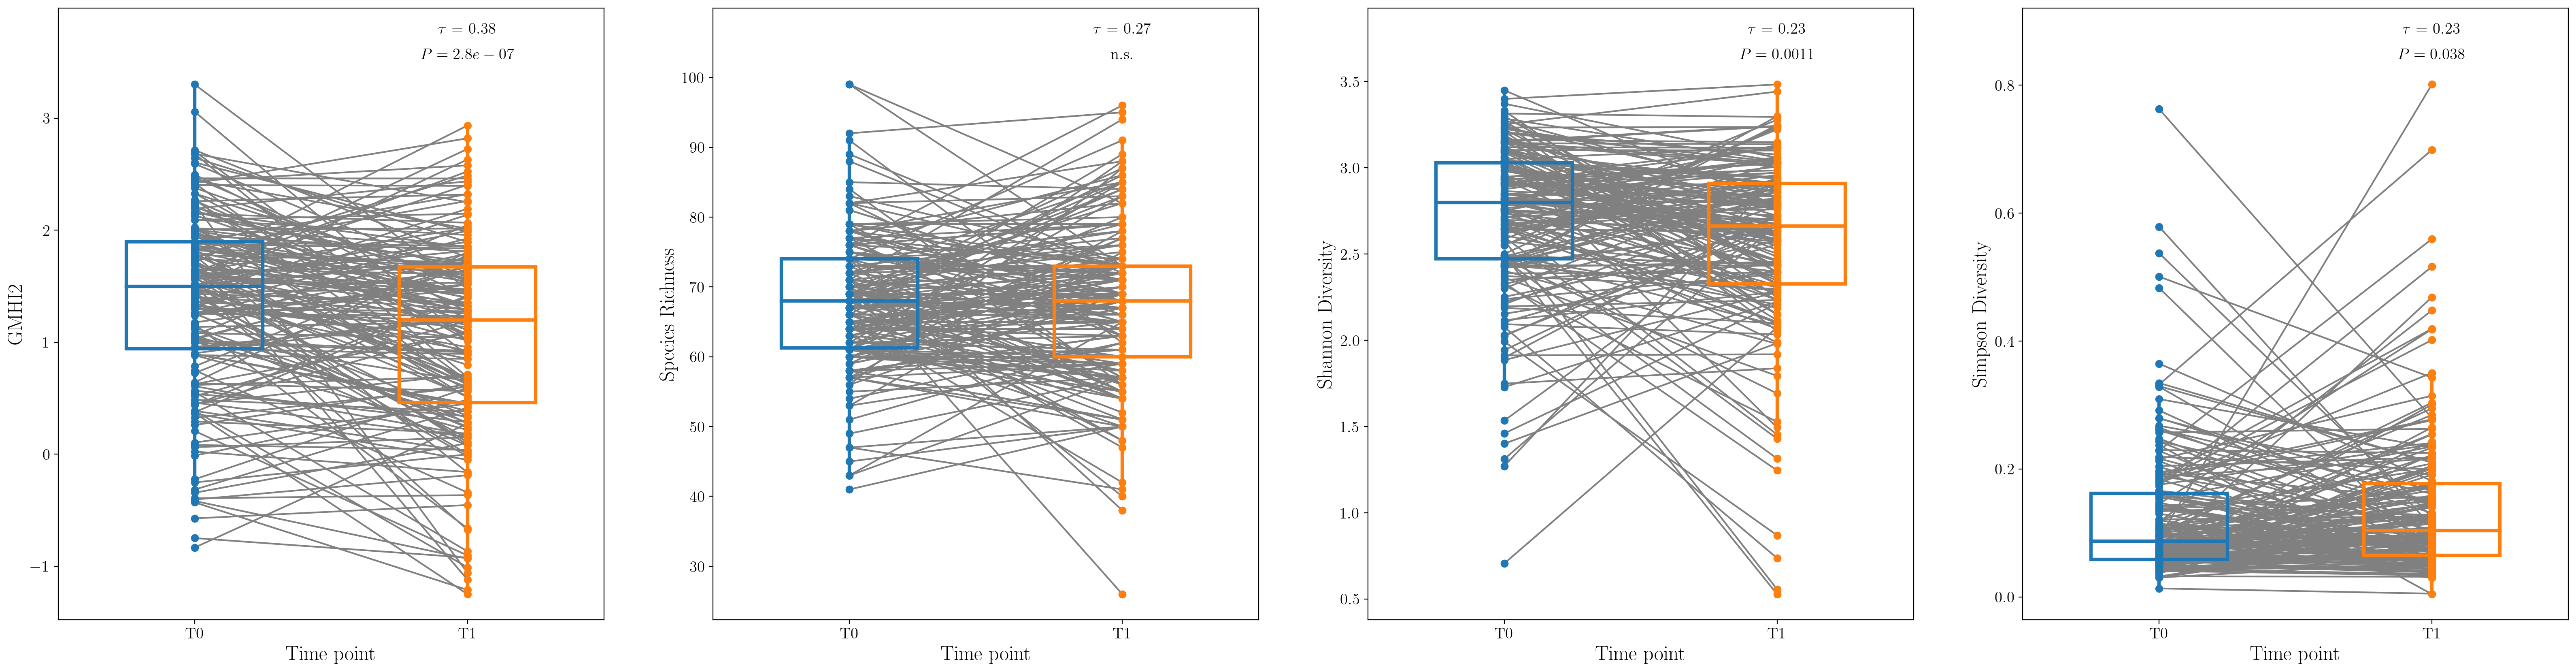

In [11]:
plot_longitudinal(meta, indices, timepoints_sorted, study, show_tau=True)

# Plot by demographic

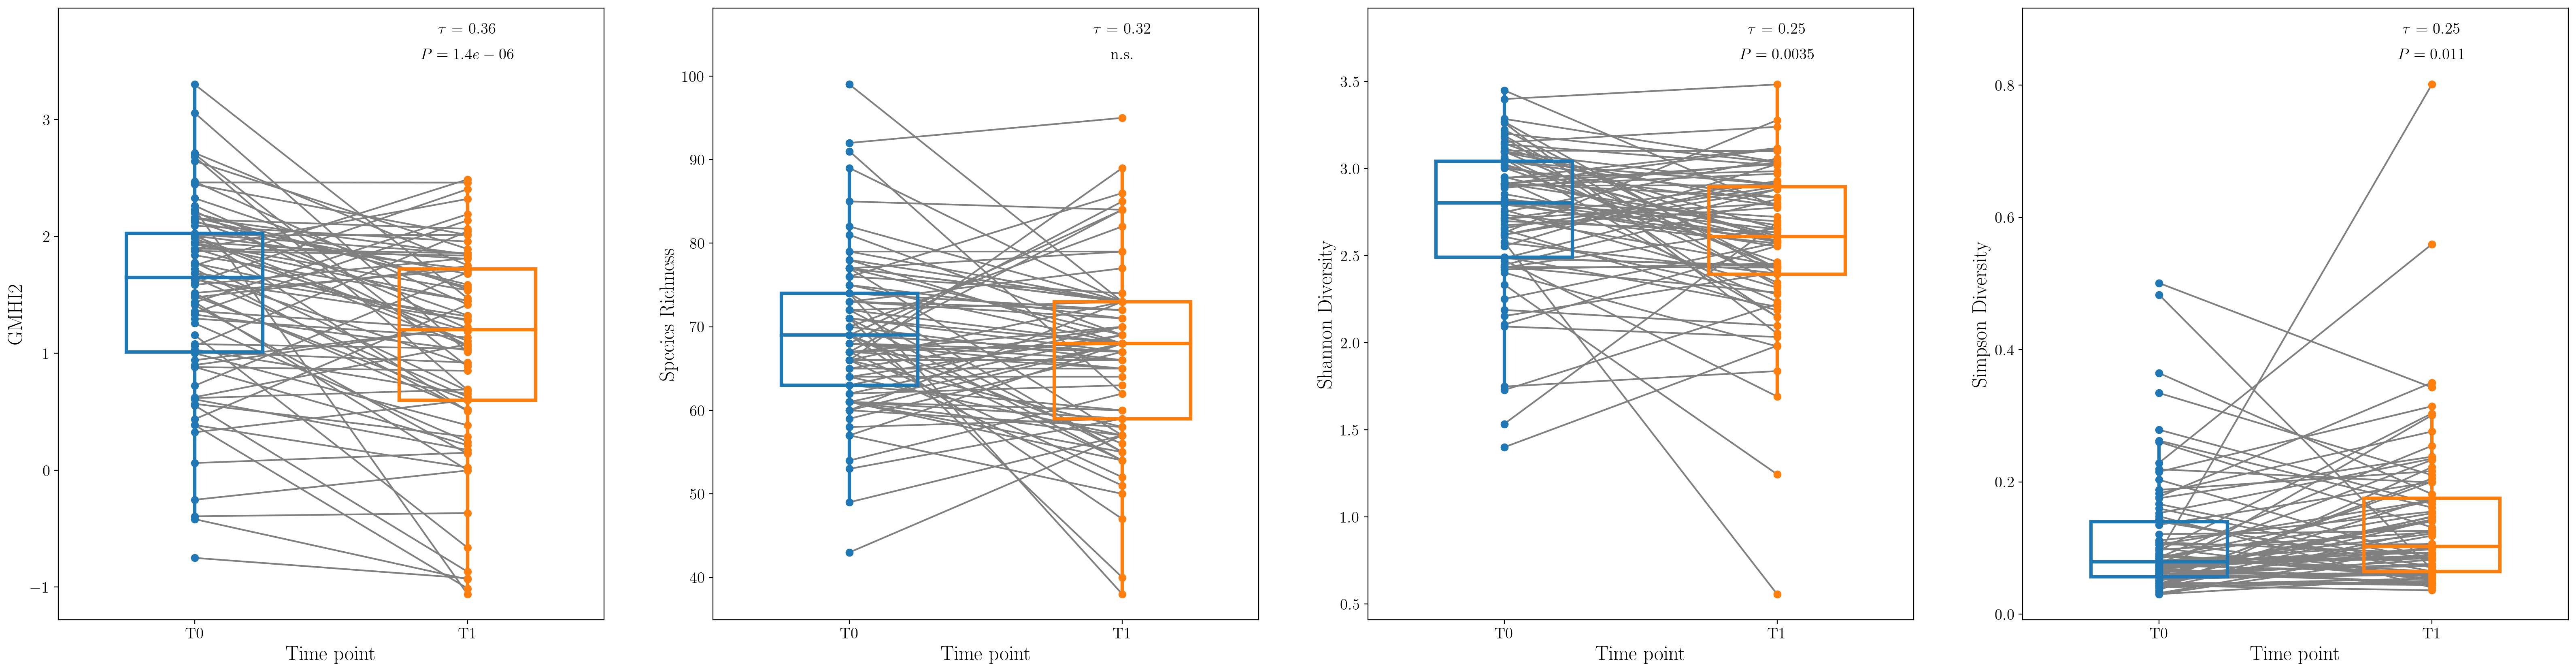

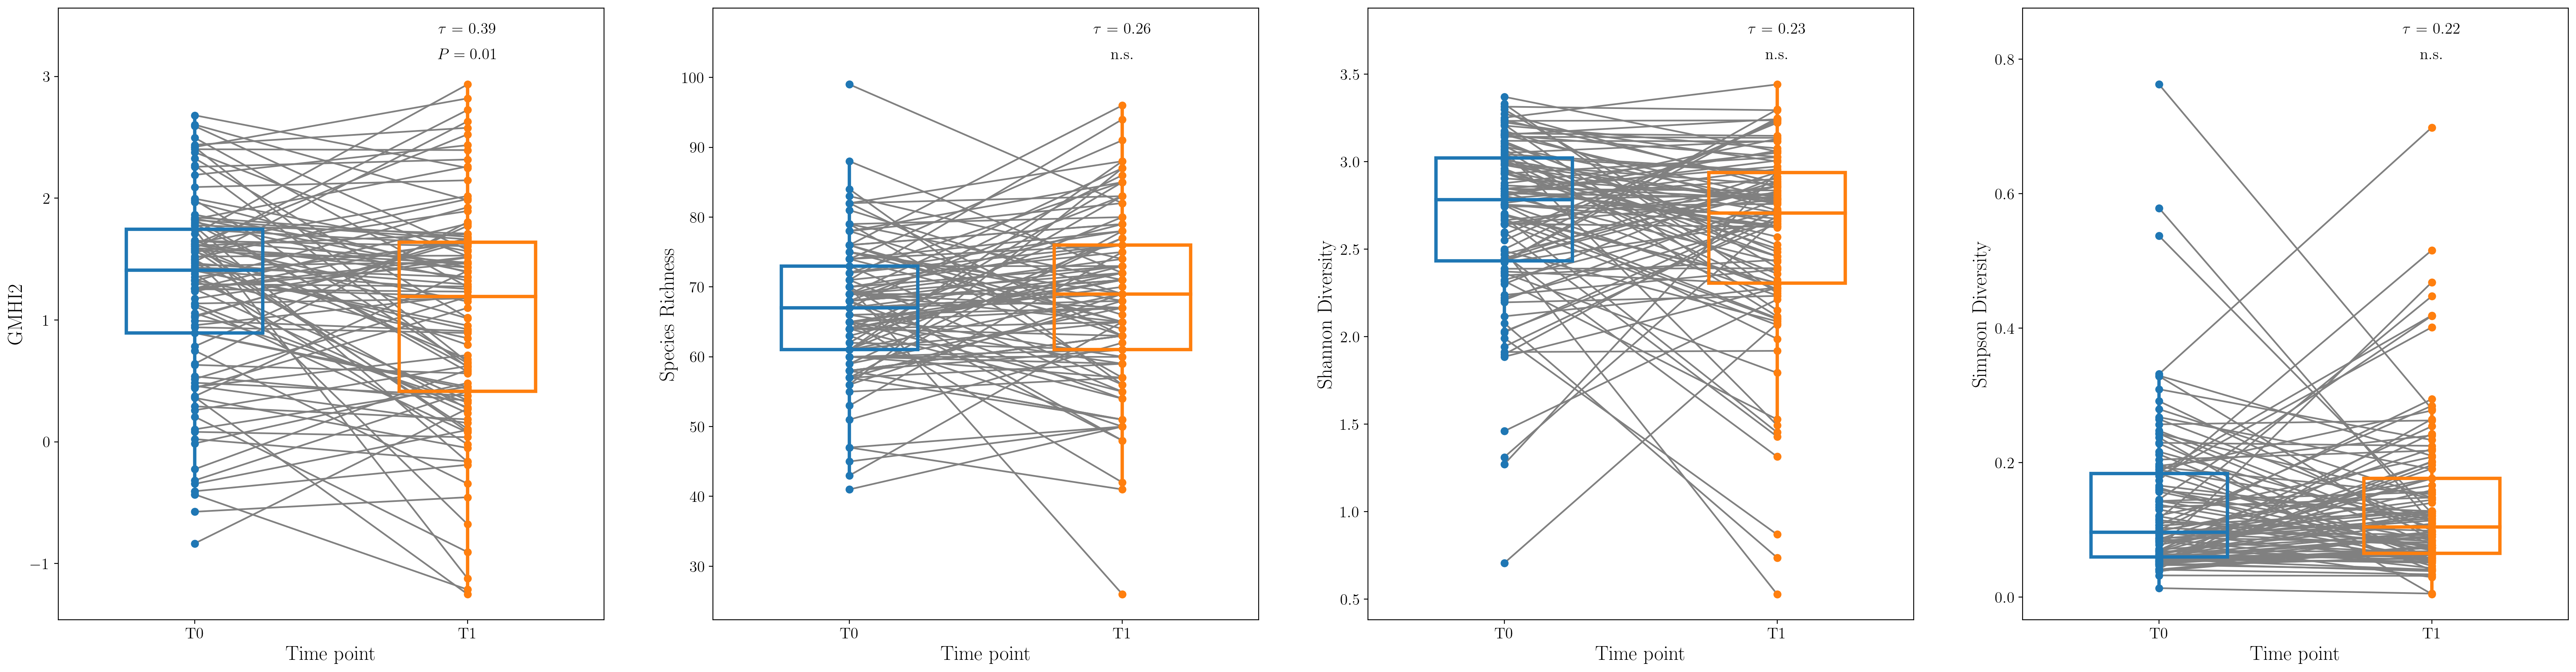

In [12]:
plot_longitudinal(meta[meta["Gender"] == "male"], indices, timepoints_sorted, study + "_male", show_tau=True)
plot_longitudinal(meta[meta["Gender"] == "female"], indices, timepoints_sorted, study + "_female", show_tau=True)

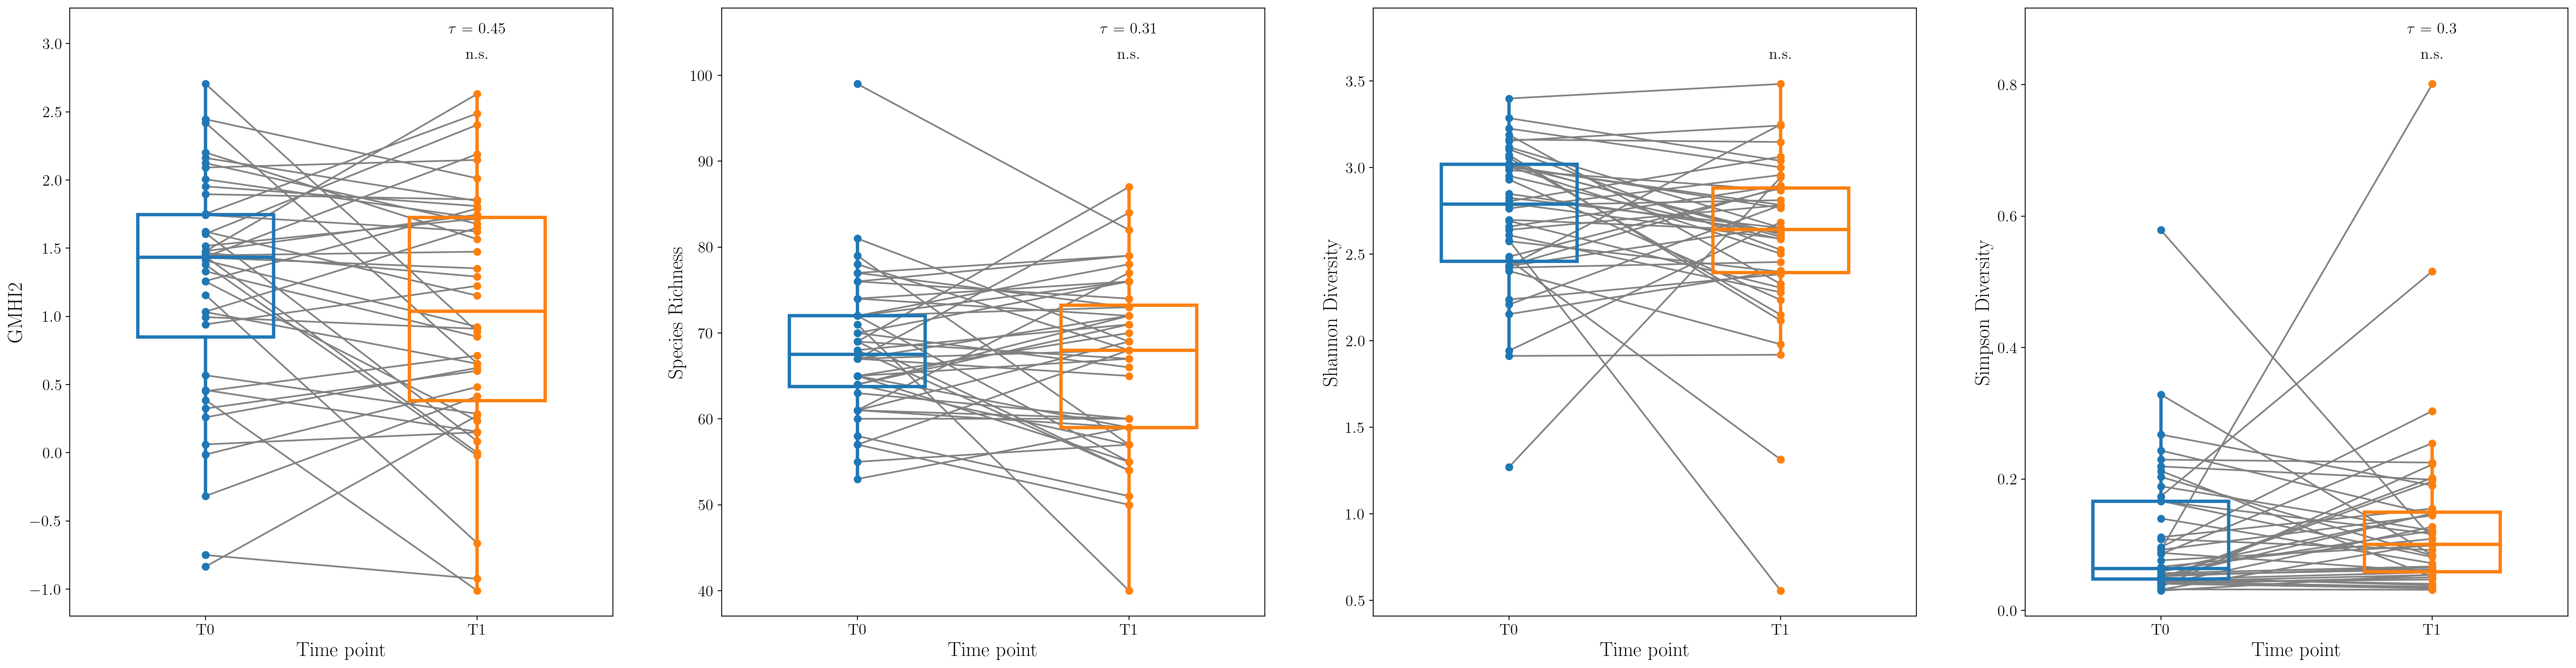

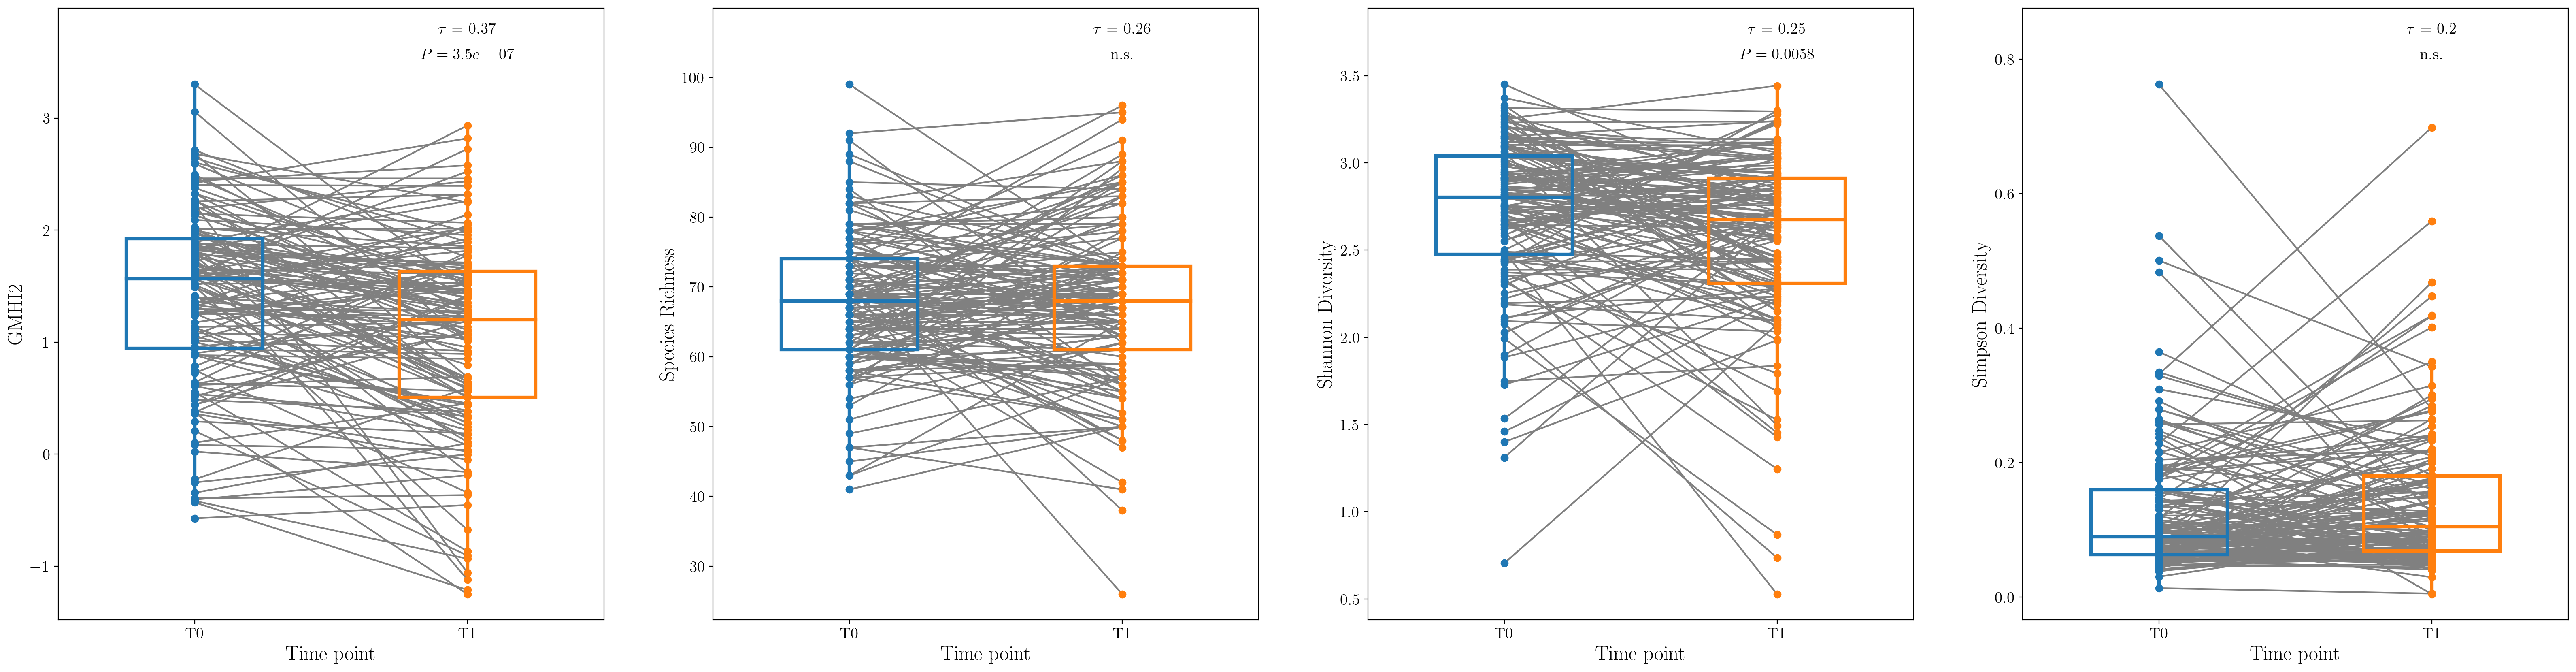

In [13]:
plot_longitudinal(meta[meta["Age (Years)"] >= 60], indices, timepoints_sorted, study + "_elder", show_tau=True)
plot_longitudinal(meta[meta["Age (Years)"] < 60], indices, timepoints_sorted, study + "_nonelder", show_tau=True)